<a href="https://colab.research.google.com/github/Rankskun/Bachelor-s-Thesis-A-Occupational-Accident-Risk-Analysis-in-the-UK-Based-on-Incident-Types-/blob/main/Bachelor_Thesis_A_Occupational_Accident_Risk_Analysis_in_the_UK_Based_on_Incident_Types_and_Industry_Sectors_Using_the_K_Means_Clustering_Algorithm_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load Data**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel('Data Kecelakaan Inggris.xlsx', skiprows=7, header=1)

print(df.head(10))

print(df.columns)

  Enforcing authority [Note 3] Year\n[Note 1]  \
0                          HSE        2019/20   
1                          HSE        2019/20   
2                          HSE        2019/20   
3                          HSE        2019/20   
4                          HSE        2019/20   
5                          HSE        2019/20   
6                          HSE        2019/20   
7                          HSE        2019/20   
8                          HSE        2019/20   
9                           LA        2019/20   

  Employment Status - overview \n[Note 4] Employment Status - detail  \
0                                 Workers                   Employee   
1                                 Workers                   Employee   
2                                 Workers                   Employee   
3                                 Workers                   Employee   
4                                 Workers              Self-employed   
5                           

**Value Count Data Awal Jenis Kecelakaan & Industri**

In [ ]:
print("=== Distribusi Awal Jenis Kecelakaan (Sebelum Dibersihkan) ===")
print(df['Kind of accident'].value_counts(dropna=False))

print("\n=== Distribusi Awal Industri (Sebelum Dibersihkan) ===")
print(df['Top-level Industry (SIC section)\n[Note 5]'].value_counts(dropna=False))


=== Distribusi Awal Jenis Kecelakaan (Sebelum Dibersihkan) ===
Kind of accident
Falls from a height                                      250
Struck by moving vehicle                                 223
Struck by moving, including flying or falling, object    119
Trapped by something collapsing or overturning            78
Slips, trips or falls on same level                       74
Other kind of accident                                    69
Drowning or asphyxiation                                  62
Contact with moving machinery                             61
Contact with electricity or electrical discharge          49
Injured by an animal                                      32
Strike against something fixed or stationary              21
Exposure to an explosion                                  10
Exposure to fire                                           9
Exposure to, or contact with, a harmful substance          7
Acts of violence                                           5
Injur

**Cleaning Data**

In [ ]:
df_clean = df[['Kind of accident', 'Top-level Industry (SIC section)\n[Note 5]']].copy()
df_clean.columns = ['Accident', 'Industry']
print("Sebelum bersih:", df_clean.shape)

df_clean.dropna(inplace=True)
print("Setelah bersih:", df_clean.shape)

print("\nMissing value:\n", df_clean.isnull().sum())
print( df_clean.head())


Sebelum bersih: (1072, 2)
Setelah bersih: (1072, 2)

Missing value:
 Accident    0
Industry    0
dtype: int64
                   Accident                                           Industry
0  Struck by moving vehicle  E - Water Supply; Sewerage, Waste Management a...
1  Exposure to an explosion  E - Water Supply; Sewerage, Waste Management a...
2       Falls from a height                     H - Transportation and storage
3  Exposure to an explosion  N - Administrative and Support Service Activities
4       Falls from a height                                   F - Construction


**Persingkat Kolom Industry**

In [ ]:
df_clean['Industry_Main'] = df_clean['Industry'].str.extract(r'-\s*([A-Za-z\s]+)')[0]
df_clean['Industry_Main'] = df_clean['Industry_Main'].fillna(df_clean['Industry'])  # fallback


print(df_clean['Industry_Main'].head())

0                                     Water Supply
1                                     Water Supply
2                       Transportation and storage
3    Administrative and Support Service Activities
4                                     Construction
Name: Industry_Main, dtype: object


**Encode Data**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_accident = LabelEncoder()
le_industry = LabelEncoder()


df_clean['Accident_Encoded'] = le_accident.fit_transform(df_clean['Accident'])
df_clean['Industry_Encoded'] = le_industry.fit_transform(df_clean['Industry_Main'])

print(df_clean[['Accident', 'Accident_Encoded']].drop_duplicates().head())
print(df_clean[['Industry_Main', 'Industry_Encoded']].drop_duplicates().head())


                                            Accident  Accident_Encoded
0                           Struck by moving vehicle                13
1                           Exposure to an explosion                 4
2                                Falls from a height                 7
5                             Other kind of accident                10
6  Struck by moving, including flying or falling,...                14
                                   Industry_Main  Industry_Encoded
0                                   Water Supply                16
2                     Transportation and storage                15
3  Administrative and Support Service Activities                 1
4                                   Construction                 4
5                     Wholesale and Retail Trade                17


**Normmalisasi Data**

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Kolom numerik asli
X = df_clean[['Accident_Encoded', 'Industry_Encoded']]

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Gabungkan jadi satu tabel perbandingan
df_compare = pd.concat(
    [X.reset_index(drop=True),
     pd.DataFrame(X_scaled,
                  columns=['Accident_Scaled',
                           'Industry_Scaled'])],
    axis=1)

print(df_compare)


      Accident_Encoded  Industry_Encoded  Accident_Scaled  Industry_Scaled
0                   13                16         0.847575         1.519235
1                    4                16        -1.234249         1.519235
2                    7                15        -0.540308         1.338878
3                    4                 1        -1.234249        -1.186114
4                    7                 4        -0.540308        -0.645044
...                ...               ...              ...              ...
1067                 7                 4        -0.540308        -0.645044
1068                 7                 4        -0.540308        -0.645044
1069                 3                 3        -1.465563        -0.825400
1070                 4                14        -1.234249         1.158522
1071                 8                 2        -0.308994        -1.005757

[1072 rows x 4 columns]


**Menentukan Jumlah Cluster (Elbow Method)**

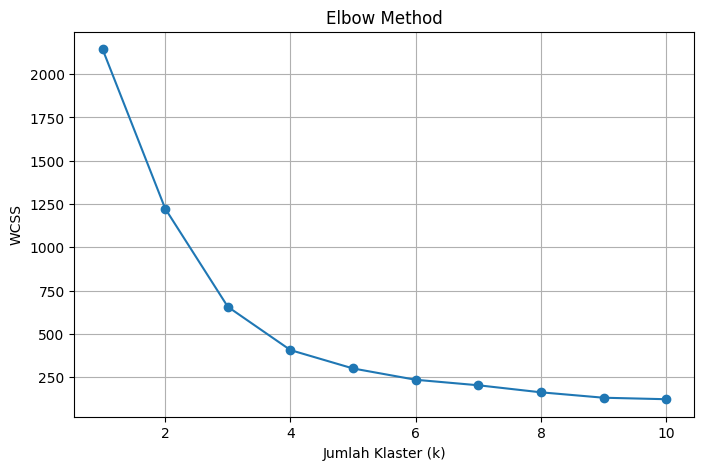

WCSS untuk setiap K: [2143.999999999998, 1223.1814218443496, 656.1095490675583, 406.03649218773467, 299.8780352682646, 234.62931018886312, 202.83571420130866, 162.13016171157778, 130.92491086401972, 122.27773288578862]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

print("WCSS untuk setiap K:", wcss)

**Clustering dengan K-Means**

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)


**Evaluasi menggunakan DBI**

In [ ]:
from sklearn.metrics import davies_bouldin_score
#Menghitung DBI untuk hasil clustering
dbi = davies_bouldin_score(X_scaled, df_clean['Cluster'])
print(f"Davies-Bouldin Index: {dbi:.4f}")


Davies-Bouldin Index: 0.7465


**Penambahan label Tingkat Resiko ***

In [ ]:
# Tambahkan kolom Cluster
df_clean['Cluster'] = kmeans.labels_

# Hitung dan beri label risiko berdasarkan centroid
centroid_df = pd.DataFrame({
    'Cluster': range(kmeans.n_clusters),
    'Tingkat Risiko': ['Tinggi', 'Sedang', 'Rendah'][:kmeans.n_clusters]
}, index=np.argsort(kmeans.cluster_centers_.sum(axis=1))[::-1])  # Urut dari tertinggi

centroid_df = centroid_df.sort_index().reset_index(drop=True)

# Pastikan tidak ada kolom ganda sebelum merge
df_clean = df_clean.drop(columns=['Tingkat Risiko'], errors='ignore')

# Gabungkan ke data utama
df_clean = df_clean.merge(centroid_df, on='Cluster', how='left')

# Tambahkan kembali kolom jika hilang
if 'Kind of accident' not in df_clean.columns and 'Kind of accident' in df.columns:
    df_clean['Kind of accident'] = df['Kind of accident'].loc[df_clean.index]


print(df_clean[['Industry_Main', 'Kind of accident', 'Cluster', 'Tingkat Risiko']].head())


                                   Industry_Main          Kind of accident  \
0                                   Water Supply  Struck by moving vehicle   
1                                   Water Supply  Exposure to an explosion   
2                     Transportation and storage       Falls from a height   
3  Administrative and Support Service Activities  Exposure to an explosion   
4                                   Construction       Falls from a height   

   Cluster Tingkat Risiko  
0        1         Sedang  
1        0         Tinggi  
2        1         Sedang  
3        0         Tinggi  
4        0         Tinggi  


**Visualisasi Cluster**

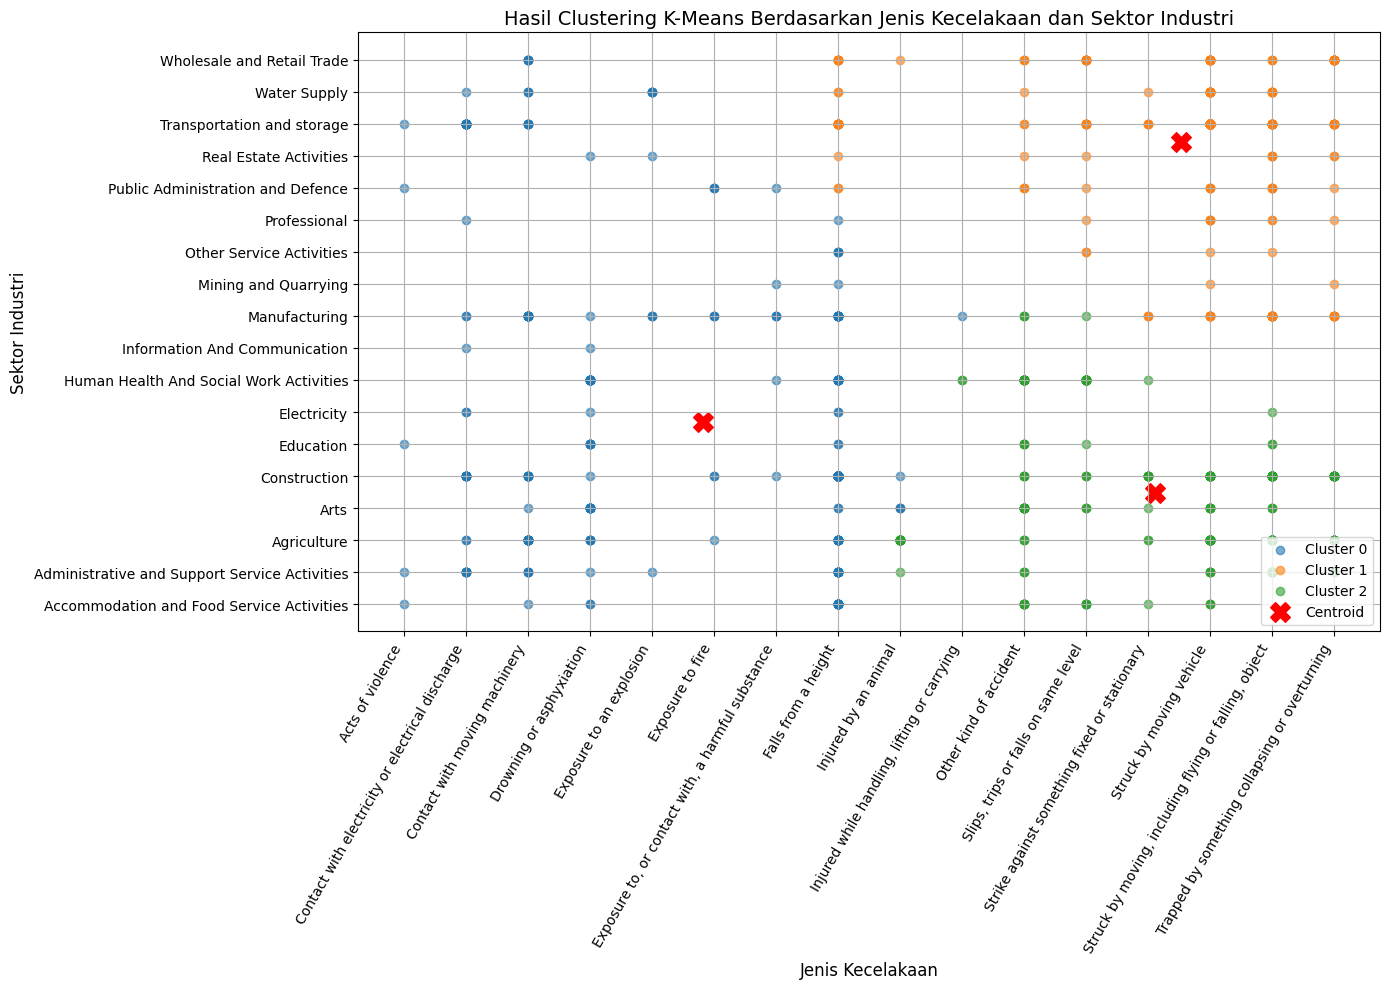

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ambil data encoded SEBELUM scaling
x_labels_encoded = df_clean['Accident_Encoded'].unique()
y_labels_encoded = df_clean['Industry_Encoded'].unique()

# Sort untuk konsistensi
x_labels_encoded.sort()
y_labels_encoded.sort()

# Ambil label aslinya dari LabelEncoder
x_labels = le_accident.inverse_transform(x_labels_encoded)
y_labels = le_industry.inverse_transform(y_labels_encoded)

# Buat figure
plt.figure(figsize=(14, 10))

# Scatter plot tiap cluster
for cluster_num in sorted(df_clean['Cluster'].unique()):
    cluster_data = X_scaled[df_clean['Cluster'] == cluster_num]
    plt.scatter(cluster_data[:, 0],
                cluster_data[:, 1],
                label=f'Cluster {cluster_num}',
                alpha=0.6)

# Plot centroid
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],
            centroids[:, 1],
            c='red',
            marker='X',
            s=200,
            label='Centroid')

# Set xticks dan yticks label (jumlah sama harus hati-hati!)
plt.xticks(
    ticks=np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), len(x_labels)),
    labels=x_labels,
    rotation=60,
    ha='right'
)

plt.yticks(
    ticks=np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), len(y_labels)),
    labels=y_labels
)

plt.xlabel("Jenis Kecelakaan", fontsize=12)
plt.ylabel("Sektor Industri", fontsize=12)
plt.title("Hasil Clustering K-Means Berdasarkan Jenis Kecelakaan dan Sektor Industri", fontsize=14)
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
for i in sorted(df_clean['Cluster'].unique()):
    print(f"\n=== Klaster {i} ===")
    print("\n>> Distribusi Industri:")
    print(df_clean[df_clean['Cluster'] == i]['Industry_Main'].value_counts())

    print("\n>> Distribusi Jenis Kecelakaan:")
    print(df_clean[df_clean['Cluster'] == i]['Accident'].value_counts())



=== Klaster 0 ===

>> Distribusi Industri:
Industry_Main
Construction                                     141
Human Health And Social Work Activities           50
Manufacturing                                     45
Agriculture                                       44
Transportation and storage                        28
Administrative and Support Service Activities     28
Accommodation and Food Service Activities         24
Arts                                              20
Education                                         10
Water Supply                                       9
Wholesale and Retail Trade                         5
Electricity                                        5
Public Administration and Defence                  5
Other Service Activities                           4
Information And Communication                      2
Professional                                       2
Mining and Quarrying                               2
Real Estate Activities                   

**Visualisasi Heatmap: Hubungan Jenis Kecelakaan & Industri**

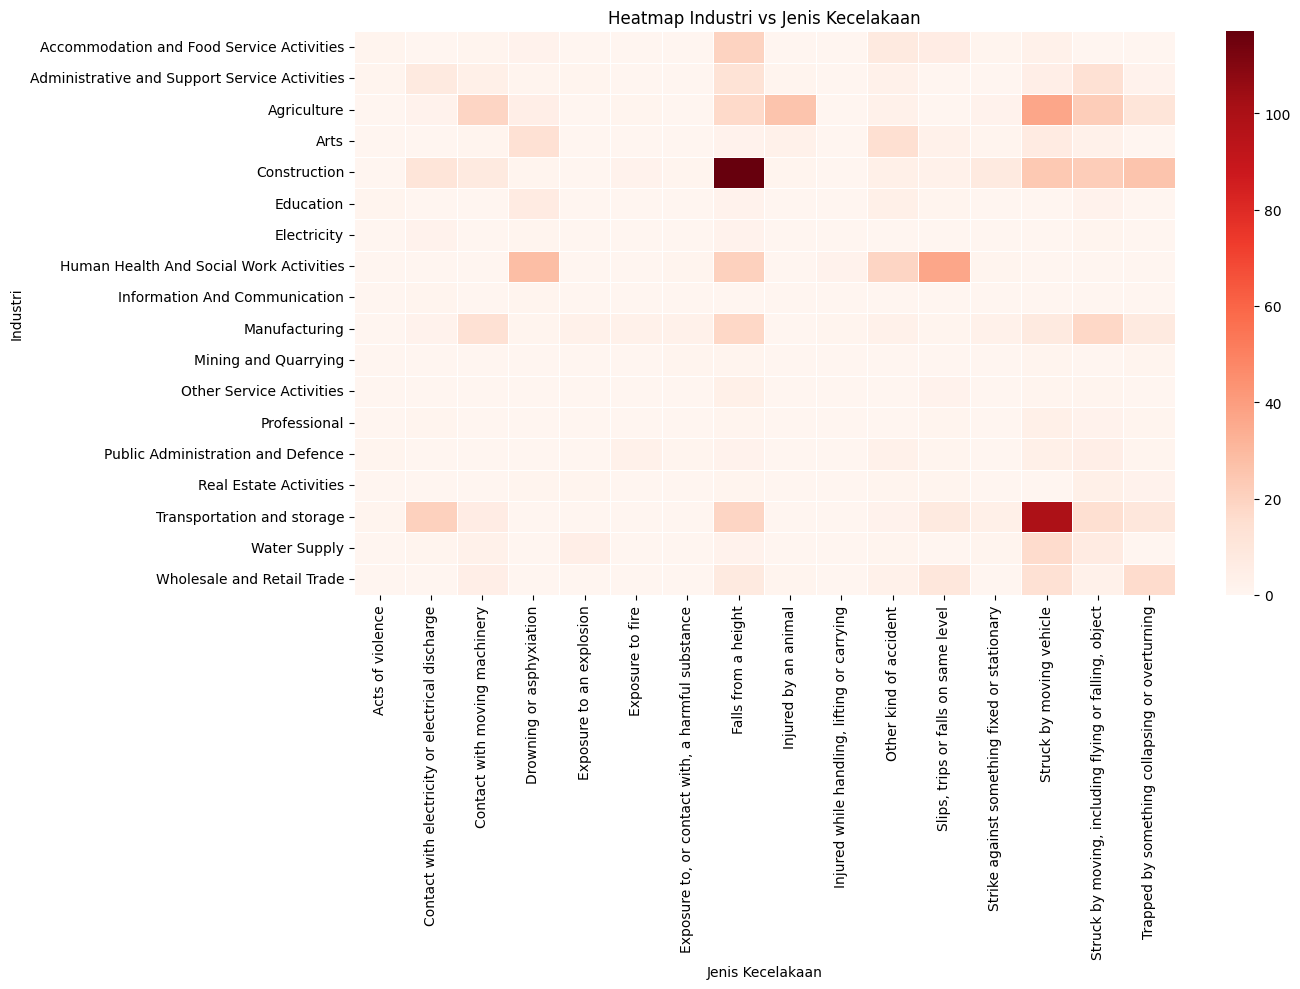

In [ ]:
import seaborn as sns

pivot = df_clean.pivot_table(index='Industry_Main', columns='Accident', aggfunc='size', fill_value=0)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, cmap='Reds', linewidths=0.5)
plt.title('Heatmap Industri vs Jenis Kecelakaan')
plt.xlabel('Jenis Kecelakaan')
plt.ylabel('Industri')
plt.tight_layout()
plt.show()


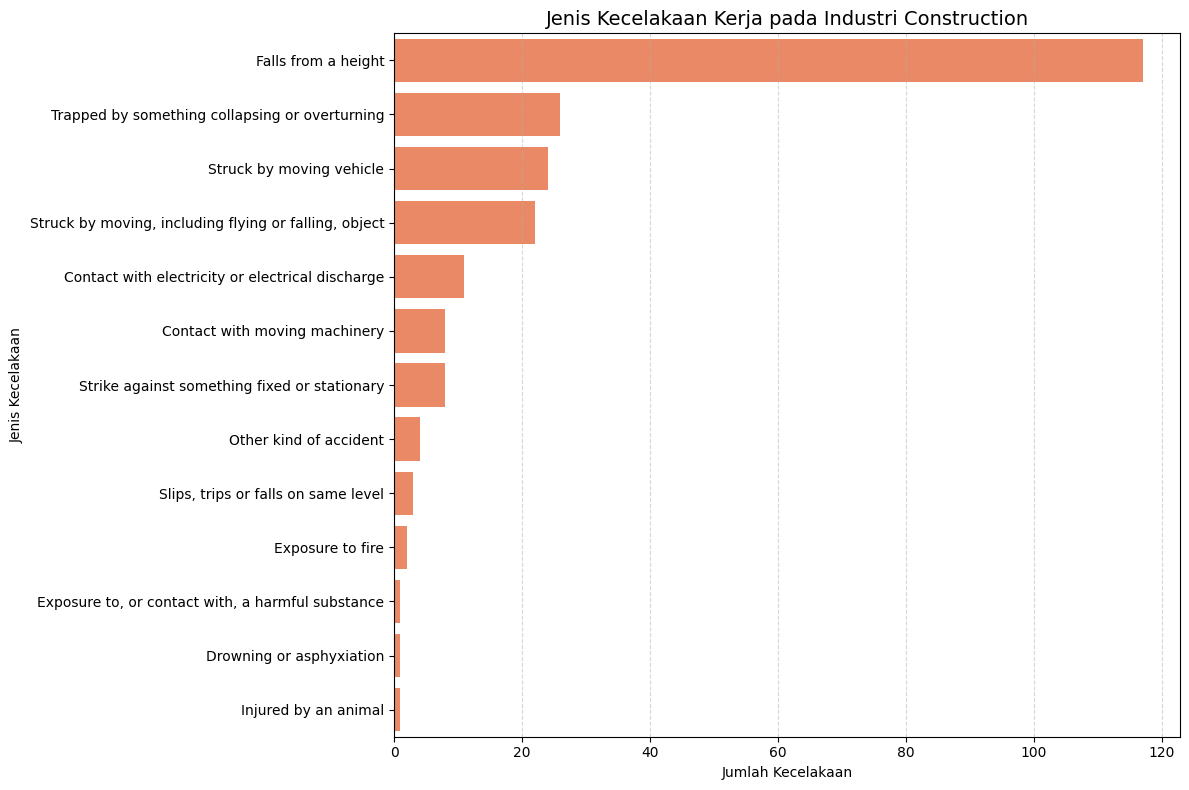

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter industri yang mengandung "Construction"
df_construction = df_clean[df_clean['Industry'].str.contains('Construction', case=False, na=False)]

# Hitung jumlah kecelakaan kerja berdasarkan jenisnya
kecelakaan_counts = df_construction['Accident'].value_counts().reset_index()
kecelakaan_counts.columns = ['Jenis_Kecelakaan', 'Jumlah']

# Visualisasi
plt.figure(figsize=(12, 8))
sns.barplot(
    data=kecelakaan_counts,
    y='Jenis_Kecelakaan',
    x='Jumlah',
    color='coral'
)

plt.title("Jenis Kecelakaan Kerja pada Industri Construction", fontsize=14)
plt.xlabel("Jumlah Kecelakaan")
plt.ylabel("Jenis Kecelakaan")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


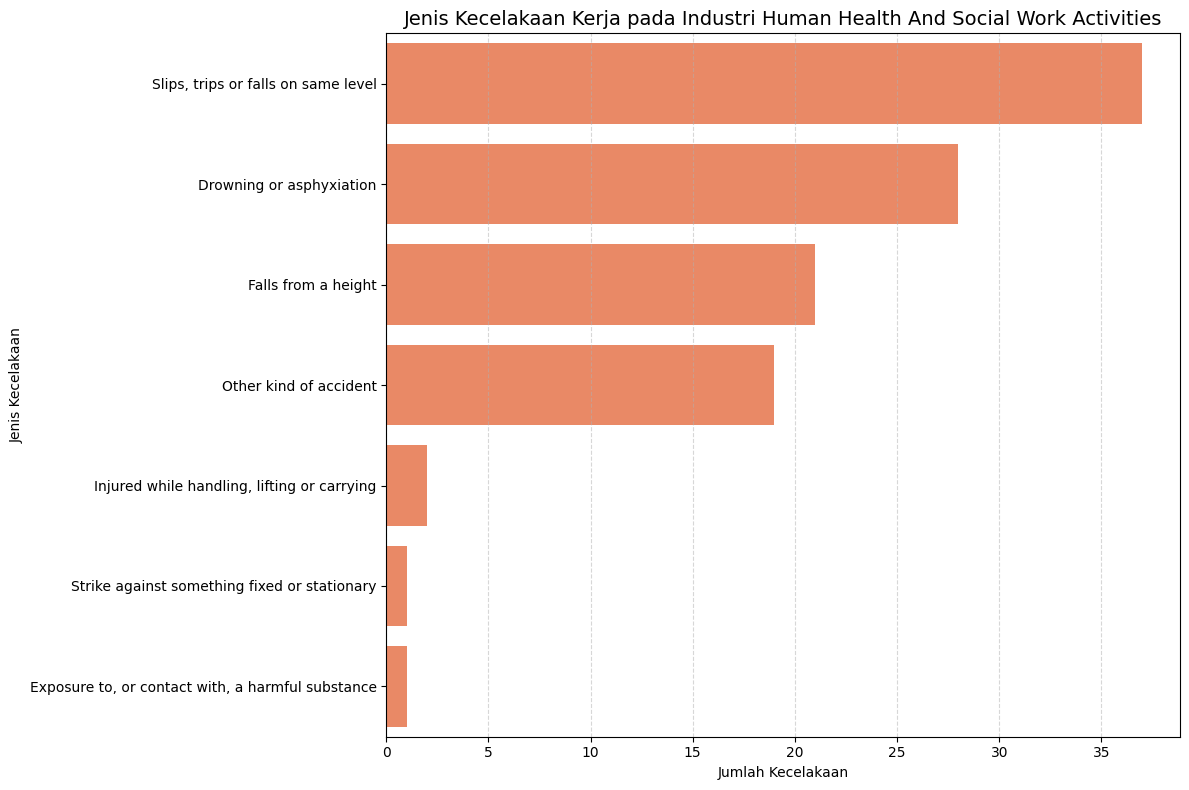

In [ ]:
ADimport matplotlib.pyplot as plt
import seaborn as sns

# Filter industri yang mengandung "Construction"
df_construction = df_clean[df_clean['Industry'].str.contains('Human Health And Social Work Activities', case=False, na=False)]

# Hitung jumlah kecelakaan kerja berdasarkan jenisnya
kecelakaan_counts = df_construction['Accident'].value_counts().reset_index()
kecelakaan_counts.columns = ['Jenis_Kecelakaan', 'Jumlah']

# Visualisasi
plt.figure(figsize=(12, 8))
sns.barplot(
    data=kecelakaan_counts,
    y='Jenis_Kecelakaan',
    x='Jumlah',
    color='coral'
)

plt.title("Jenis Kecelakaan Kerja pada Industri Human Health And Social Work Activities", fontsize=14)
plt.xlabel("Jumlah Kecelakaan")
plt.ylabel("Jenis Kecelakaan")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


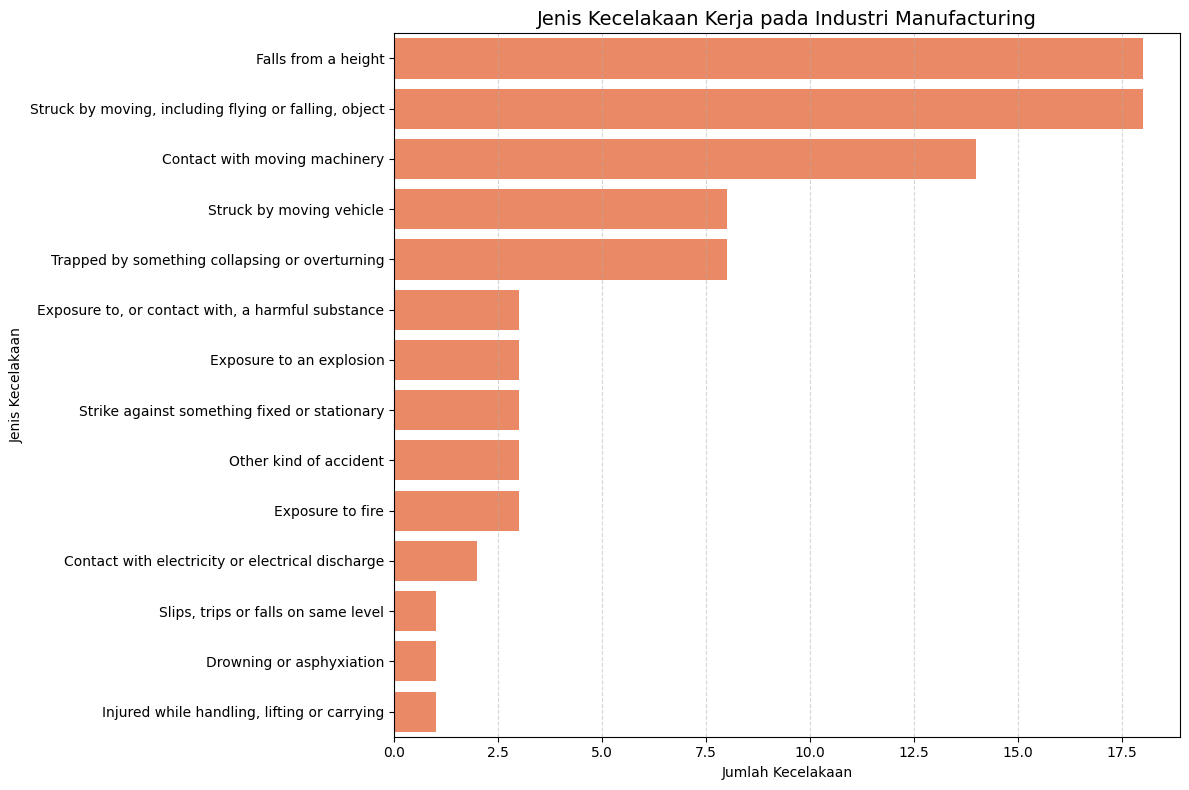

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter industri yang mengandung "Construction"
df_construction = df_clean[df_clean['Industry'].str.contains('Manufacturing', case=False, na=False)]

# Hitung jumlah kecelakaan kerja berdasarkan jenisnya
kecelakaan_counts = df_construction['Accident'].value_counts().reset_index()
kecelakaan_counts.columns = ['Jenis_Kecelakaan', 'Jumlah']

# Visualisasi
plt.figure(figsize=(12, 8))
sns.barplot(
    data=kecelakaan_counts,
    y='Jenis_Kecelakaan',
    x='Jumlah',
    color='coral'
)

plt.title("Jenis Kecelakaan Kerja pada Industri Manufacturing", fontsize=14)
plt.xlabel("Jumlah Kecelakaan")
plt.ylabel("Jenis Kecelakaan")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


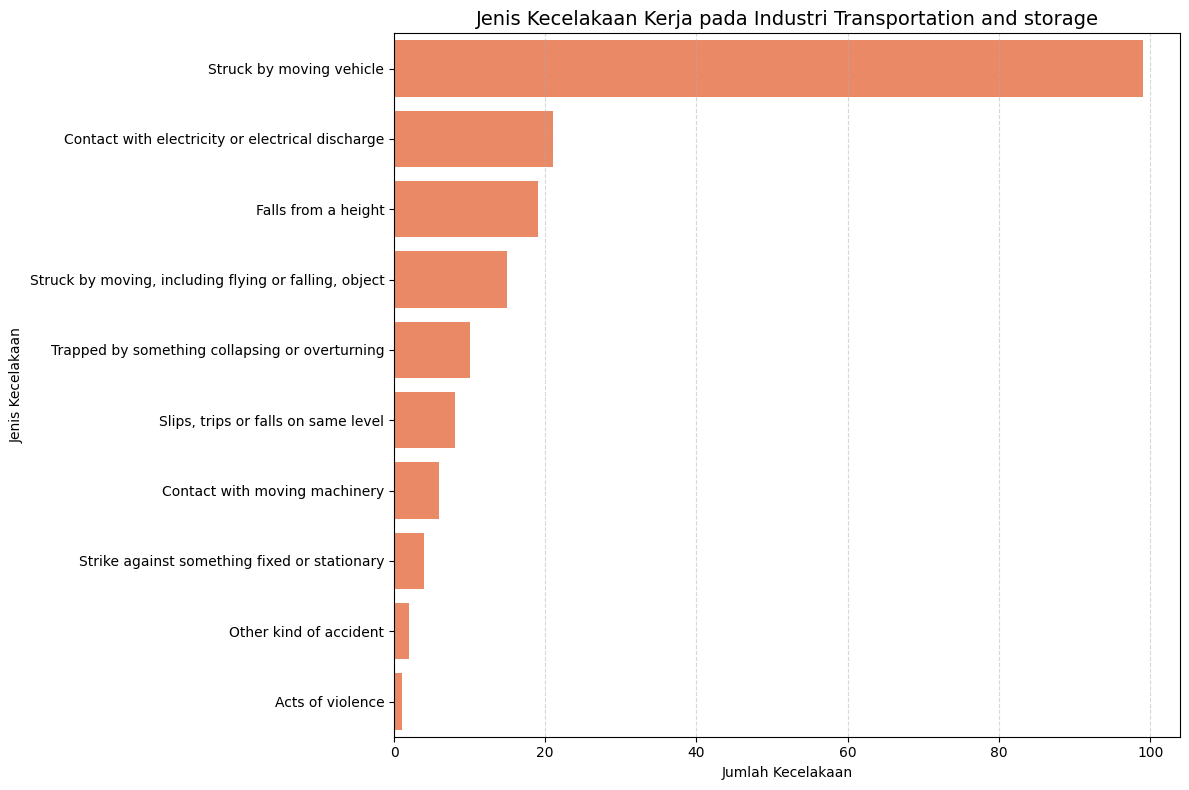

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter industri yang mengandung "Construction"
df_construction = df_clean[df_clean['Industry'].str.contains('Transportation and storage', case=False, na=False)]

# Hitung jumlah kecelakaan kerja berdasarkan jenisnya
kecelakaan_counts = df_construction['Accident'].value_counts().reset_index()
kecelakaan_counts.columns = ['Jenis_Kecelakaan', 'Jumlah']

# Visualisasi
plt.figure(figsize=(12, 8))
sns.barplot(
    data=kecelakaan_counts,
    y='Jenis_Kecelakaan',
    x='Jumlah',
    color='coral'
)

plt.title("Jenis Kecelakaan Kerja pada Industri Transportation and storage", fontsize=14)
plt.xlabel("Jumlah Kecelakaan")
plt.ylabel("Jenis Kecelakaan")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


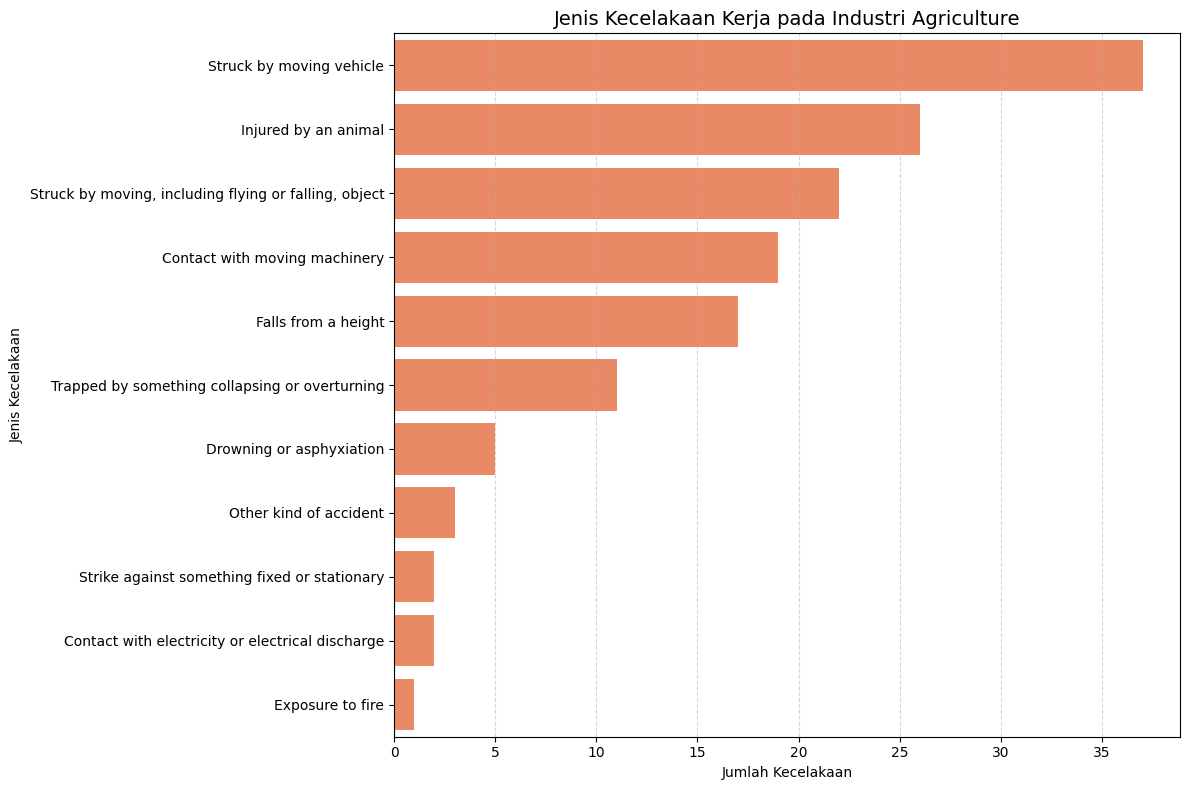

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter industri yang mengandung "Construction"
df_construction = df_clean[df_clean['Industry'].str.contains('Agriculture', case=False, na=False)]

# Hitung jumlah kecelakaan kerja berdasarkan jenisnya
kecelakaan_counts = df_construction['Accident'].value_counts().reset_index()
kecelakaan_counts.columns = ['Jenis_Kecelakaan', 'Jumlah']

# Visualisasi
plt.figure(figsize=(12, 8))
sns.barplot(
    data=kecelakaan_counts,
    y='Jenis_Kecelakaan',
    x='Jumlah',
    color='coral'
)

plt.title("Jenis Kecelakaan Kerja pada Industri Agriculture", fontsize=14)
plt.xlabel("Jumlah Kecelakaan")
plt.ylabel("Jenis Kecelakaan")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Visualisasi Tingkat Risiko Kecelakaan Industri**

/tmp/ipython-input-17-3426861455.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


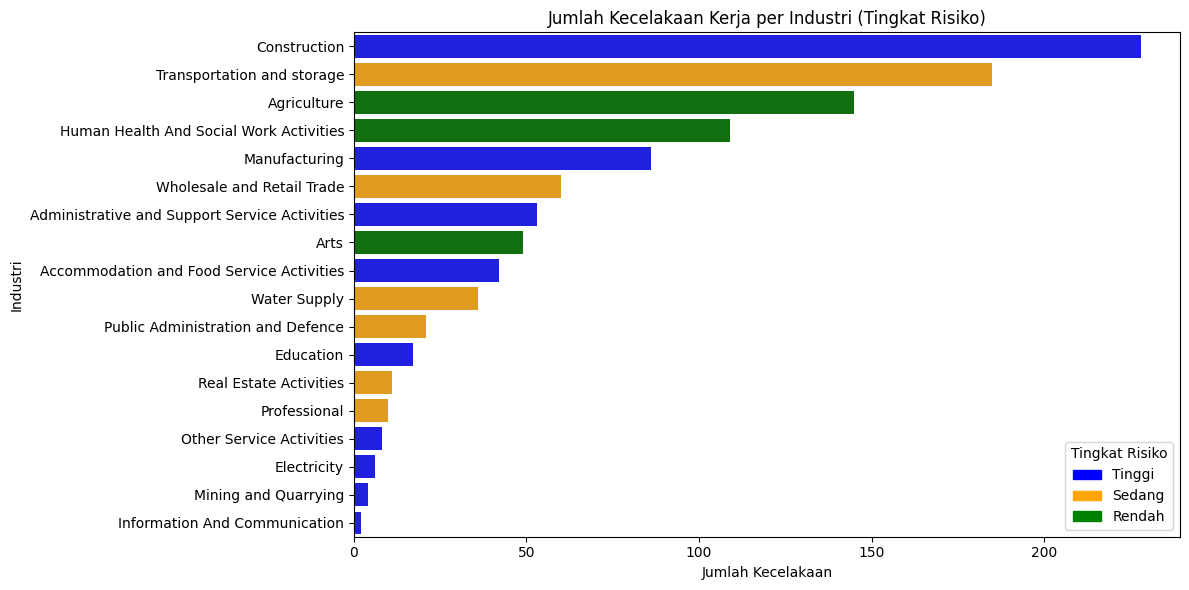

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Hitung total kecelakaan per industri
total_kecelakaan = df_clean.groupby('Industry_Main').size().reset_index(name='Jumlah_Kecelakaan')

# Hitung jumlah per tingkat risiko untuk tiap industri
risk_counts = df_clean.groupby(['Industry_Main', 'Tingkat Risiko']).size().reset_index(name='Jumlah_Risiko')

#  Ambil tingkat risiko dominan untuk setiap industri
dominant_risk = risk_counts.sort_values('Jumlah_Risiko', ascending=False).drop_duplicates('Industry_Main')

# Gabungkan total kecelakaan + risiko dominan
final_df = pd.merge(total_kecelakaan, dominant_risk[['Industry_Main', 'Tingkat Risiko']], on='Industry_Main')

# Atur warna
warna = {
    'Tinggi': 'blue',
    'Sedang': 'orange',
    'Rendah': 'green'
}

# 6Urutkan industri berdasarkan jumlah kecelakaan tertinggi
ordered_industries = final_df.sort_values('Jumlah_Kecelakaan', ascending=False)['Industry_Main']

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=final_df,
    y='Industry_Main',
    x='Jumlah_Kecelakaan',
    order=ordered_industries,
    palette=[warna[r] for r in final_df.set_index('Industry_Main').loc[ordered_industries]['Tingkat Risiko']]
)
plt.title('Jumlah Kecelakaan Kerja per Industri (Tingkat Risiko)')
plt.xlabel('Jumlah Kecelakaan')
plt.ylabel('Industri')

#Tambahkan legenda manual
legend_handles = [Patch(color=c, label=r) for r, c in warna.items()]
plt.legend(handles=legend_handles, title='Tingkat Risiko')

plt.tight_layout()
plt.show()
